# 🎤 PROJE 4 — Eurovision (Gerçek 2000-2023 Verisi)
## Mini Proje — Araştırma Projeniz
*Bugün (Gün 2) seçtiğiniz proje — kampın son günü "Bilimsel Yöntem" oturumunda sunulacak*

**Veri seti:** 916 GERÇEK Eurovision katılımı, 2000-2023 arası, 50 ülke + 21165 oy kaydı

📊 **Bu sentetik DEĞİL** — Spijkervet'in açık kaynak veri tabanından, eurovisionworld.com kayıtlarına dayalı gerçek puanlar.

### 🎯 Sizin Göreviniz
Eurovision'da **kim niye kazanır?** Gerçek veriden öğrenelim!

**Aşağıdaki seçeneklerden en az 2'sini deneyin:**
1. **Türkiye'nin Eurovision tarihi** (2000-2012, 13 yıl) — kim ne yaptı?
2. **Ev sahibi avantajı** gerçek mi?
3. **Sahnedeki çıkış sırası** etkili mi?
4. **Tele vs jüri puanı** — halk ile uzmanlar arasında fark var mı?
5. 🌍 **Coğrafya etkisi:** Komşu ülkeler birbirine daha mı çok oy veriyor?
6. Bir ülkenin **ilk 10'a girip girmeyeceğini** tahmin eden model eğitin

---

> 🤖 **Bu, defterin "çıktılı önizleme" sürümüdür.** Asıl çalışacağınız Colab defteri
> [`notebooks/`](../notebooks) klasöründe. Buraya, normal hücrelerin **arasına**:
> 📂 *veri açıklamaları*, 📊 *her grafiğin/istatistiğin ne anlattığı*, 🔧 *deneyebileceğiniz
> varyasyonlar* (çalıştırılmış hâlde) ve mini projelerde 🎤 *sunum rehberleri* eklendi.
> Bu eklemeler **alıntı kutularıyla** ayrılmıştır; siz de aynı şeyleri kendi defterinizde deneyebilirsiniz.


In [2]:
import os
from python_code.helper_tr import *
import pandas as pd

esc = veri_yukle('input_data/eurovision.csv')
print(f'\nÜlke sayısı: {esc["ulke"].nunique()}, Yıl sayısı: {esc["yil"].nunique()}')
print(f'Türkiye katılımları: {sorted(esc[esc["ulke"] == "Türkiye"]["yil"].tolist())}')


📂 'input_data/eurovision.csv' okunuyor...
✅ Yüklendi: 916 satır × 18 sütun

İlk 5 satır:
    yil       ulke         sanatci                     sarki  yari_final_no  \
0  2000  Danimarka  Olsen brothers  Fly On The Wings Of Love            NaN   
1  2000      Rusya           Alsou                      Solo            NaN   
2  2000    Letonya      BrainStorm                   My Star            NaN   
3  2000    Estonya            Ines        Once In A Lifetime            NaN   
4  2000    Almanya     Stefan Raab      Wadde Hadde Dudde Da            NaN   

   final_cikis_sirasi  final_sira  final_puan  tele_puan_final  \
0                14.0         1.0       195.0              NaN   
1                 9.0         2.0       155.0              NaN   
2                21.0         3.0       136.0              NaN   
3                 4.0         4.0        98.0              NaN   
4                15.0         5.0        96.0              NaN   

   juri_puan_final  yarifinal_cikis_sir

## 📂 Veriyi Tanıyalım — Eurovision (2000–2023)

İki veri seti birlikte kullanılıyor:
1. **`eurovision.csv`** — her satır bir ülkenin bir yıldaki katılımı (**916 satır, 50 ülke**). Sanatçı, şarkı, final sırası/puanı, ev sahibi mi, sahne çıkış sırası, ev sahibine uzaklık (km), ‘ilk 10'a girdi mi’ gibi bilgiler.
2. **`eurovision_oylar.csv`** — her satır ‘X ülkesi Y ülkesine kaç puan verdi’ (**21.165 satır**). Komşu oylamasını incelemek için.

Önemli sütunlar: `final_sira` (1 = birinci, **küçük = iyi!**), `final_puan`, `ev_sahibi`, `ev_sahibi_uzaklik_km`, `ilk_10`, `tele_puan_final` (halk), `juri_puan_final` (jüri).

💬 **Akranlarına anlat:** *“Eurovision sadece şarkı yarışması mı, yoksa coğrafya ve siyaset de işin içinde mi? Gerçek veriyle bakacağız.”* 💡 Sıralamada **küçük sayı iyidir** (1 = şampiyon); grafiklerde y eksenini bu yüzden ters çeviriyoruz.

---
### 👥 Grup Tartışması — Başlamadan Önce
- Eurovision'da bir şarkının kazanmasını ne belirler sizce — **şarkının kalitesi**, **ülkeler arası dostluk/komşuluk**, yoksa **sahne sırası** mı? Grupça en önemli **3 faktörü** tahmin edin.
- Bu tahminleri notebook'un sonunda model gerçekten doğrulayacak mı, beraber göreceğiz.

## Adım 1: Veriyi tanıyın

Sütunlar:
- `yil`, `ulke`, `sanatci`, `sarki`
- `final_sira`: Final sıralaması (1 = kazanan)
- `final_puan`: Final puan toplamı
- `tele_puan_final`, `juri_puan_final`: Halk vs jüri (2016+)
- `final_cikis_sirasi`: Sahnedeki çıkış sırası
- `ev_sahibi`, `ev_sahibi_ulke`: Ev sahipliği bilgisi
- 🌍 **`ev_sahibi_uzaklik_km`: Ev sahibi ülkeye olan kilometre uzaklığı**
- `ilk_10`: Final sıralaması ≤ 10?

In [3]:
veriyi_ozetle(esc)

📊 Veri boyutu: 916 satır × 18 sütun

Sütun tipleri:
yil                         int64
ulke                       object
sanatci                    object
sarki                      object
yari_final_no             float64
final_cikis_sirasi        float64
final_sira                float64
final_puan                float64
tele_puan_final           float64
juri_puan_final           float64
yarifinal_cikis_sirasi    float64
yarifinal_sira            float64
yarifinal_puan            float64
finale_kaldı                 bool
ev_sahibi                    bool
ev_sahibi_ulke             object
ev_sahibi_uzaklik_km      float64
ilk_10                       bool
dtype: object

Eksik değer sayısı (sütun başına):
yil                         0
ulke                        0
sanatci                     0
sarki                       1
yari_final_no             276
final_cikis_sirasi        336
final_sira                337
final_puan                337
tele_puan_final           735
juri_puan_final 

📊 **Genel özet:** 916 katılım var ve bazı sütunlarda **eksik değerler** görürsün (örn. finale kalamayanların final puanı boştur). Bu bir hata değil, gerçeğin yansımasıdır — herkes finale çıkamaz. İleride bu yüzden ‘finale kalanlar’ı süzeceğiz.

## Adım 2: 🇹🇷 Türkiye'nin Eurovision Tarihi

**Önemli gerçek:** Türkiye 2000-2012 arası 13 yıl katıldı, 2013'ten sonra çekildi. 2003'te **Sertab Erener** ile şampiyon oldu ("Every Way That I Can")!

In [4]:
tr = esc[esc['ulke'] == 'Türkiye'].sort_values('yil')
print(tr[['yil', 'sanatci', 'sarki', 'final_sira', 'final_puan']].to_string(index=False))

 yil                   sanatci                    sarki  final_sira  final_puan
2000 Pinar Ayhan & S.O.S. band            Yorgunum Anla        10.0        59.0
2001                Sedat Yüce            Sevgiliye Son        11.0        41.0
2002   Buket Bengisu & Saphire Leylaklar Soldu Kalbinde        16.0        29.0
2003             Sertab Erener      Everyway That I Can         1.0       167.0
2004                    Athena                 For Real         4.0       195.0
2005                  Gülseren            Rimi Rimi Ley        13.0        92.0
2006               Sibel Tüzün                Superstar        11.0        91.0
2007              Kenan Dogulu     Shake It Up Shekerim         4.0       163.0
2008              Mor ve Ötesi                     Deli         7.0       138.0
2009                    Hadise              Düm Tek Tek         4.0       177.0
2010                     maNga     We Could Be The Same         2.0       170.0
2011            Yüksek Sadakat          

📊 **Türkiye tablosu:** Yıl yıl sanatçı, şarkı, final sırası ve puanı. Verinin ‘ham’ hâlini görmek, grafiklere geçmeden önce neyle çalıştığını anlamanı sağlar — örn. 2003'teki 1.'liği (Sertab Erener) burada gözle bulabilirsin.

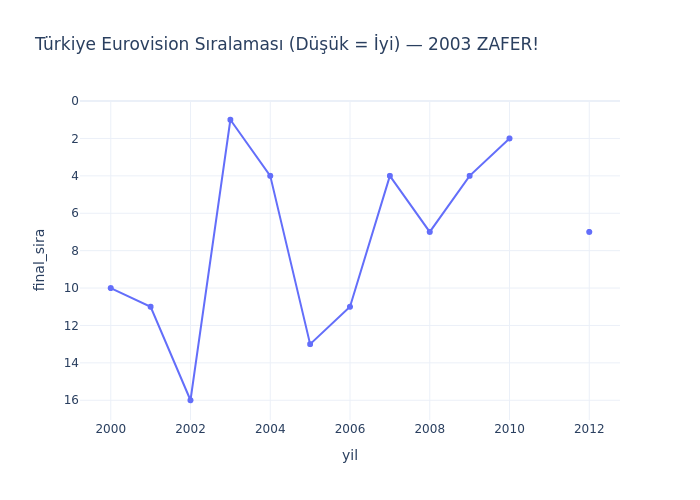

In [5]:
import plotly.express as px
fig = px.line(tr, x='yil', y='final_sira', markers=True,
              hover_data=['sanatci', 'sarki', 'final_puan'],
              title='Türkiye Eurovision Sıralaması (Düşük = İyi) — 2003 ZAFER!')
fig.update_yaxes(autorange='reversed')
fig.show()

📊 **Türkiye sıralama grafiği:** Y ekseni **ters** (1 = en üstte, çünkü 1. olmak iyidir). Çizginin inişli-çıkışlı olması ‘istikrarsızlık’, dibe yakın seyretmesi ‘istikrarlı başarı’ demektir.

🔧 **Başka bir ülkenin hikâyesini çiz.** En başarılılardan İsveç nasıl?

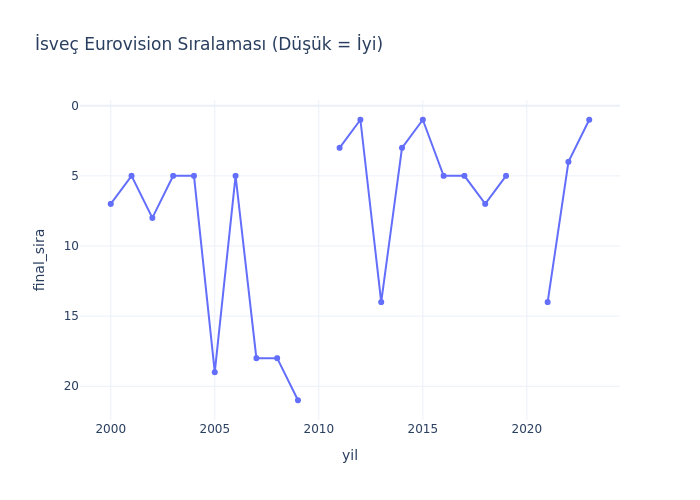

In [6]:
isvec = esc[esc['ulke'] == 'İsveç'].sort_values('yil')
fig = px.line(isvec, x='yil', y='final_sira', markers=True,
              hover_data=['sanatci', 'sarki'],
              title='İsveç Eurovision Sıralaması (Düşük = İyi)')
fig.update_yaxes(autorange='reversed')
fig.show()

📊 İsveç sürekli üst sıralarda gezerken Türkiye daha **inişli çıkışlıdır**: *istikrar* mı yoksa *tek bir parlak yıl* mı — çizginin şekli bunu anlatır.

**Görev:** Türkiye'nin en iyi yılı? Kim, hangi şarkı? En kötü yılı?

---
### 👥 Grup Tartışması
- Türkiye 2012'den sonra Eurovision'a katılmadı. Bir ülke neden böyle bir yarışmadan **çekilir**? Grupça olası sebepleri sıralayın.
- Bir yarışma 'adil değil' diye düşünülüyorsa çekilmek mi doğru, yoksa içeride kalıp değiştirmeye çalışmak mı?

## Adım 3: En çok kazananlar

In [7]:
kazananlar = esc[esc['final_sira'] == 1]
print('En çok kazanan ülkeler (2000-2023):')
print(kazananlar['ulke'].value_counts().head(10))
print('\nTüm 2000-2023 kazananları:')
print(kazananlar[['yil', 'ulke', 'sanatci', 'sarki']].to_string(index=False))

En çok kazanan ülkeler (2000-2023):
ulke
İsveç         3
Ukrayna       3
Danimarka     2
Estonya       1
Türkiye       1
Letonya       1
Finlandiya    1
Sırbistan     1
Rusya         1
Yunanistan    1
Name: count, dtype: int64

Tüm 2000-2023 kazananları:
 yil       ulke                        sanatci                    sarki
2000  Danimarka                 Olsen brothers Fly On The Wings Of Love
2001    Estonya Tanel Padar, Dave Benton & 2XL                Everybody
2002    Letonya                        Marie N                  I Wanna
2003    Türkiye                  Sertab Erener      Everyway That I Can
2004    Ukrayna                        Ruslana              Wild Dances
2005 Yunanistan               Helena Paparizou            My Number One
2006 Finlandiya                          Lordi     Hard Rock Hallelujah
2007  Sırbistan               Marija Šerifović                  Molitva
2008      Rusya                     Dima Bilan                  Believe
2009     Norveç          

📊 **En çok kazananlar:** İsveç ve Ukrayna başı çekiyor (3'er zafer); Türkiye'nin 1 zaferi var. Bu çıktı, ‘hangi ülkeler tarihsel olarak güçlü?’ bağlamını verir — ileride modelin neden bazı ülkeleri ‘avantajlı’ gördüğünü anlamana yardımcı olur.

## Adım 4 (Seçenek): Ev Sahibi Avantajı

In [8]:
finale_kalanlar = esc[esc['finale_kaldı']]
ev = finale_kalanlar[finale_kalanlar['ev_sahibi']]['final_sira'].mean()
diger = finale_kalanlar[~finale_kalanlar['ev_sahibi']]['final_sira'].mean()
print(f'Ev sahibi ortalama sıra: {ev:.1f}')
print(f'Diğer ülkeler ortalama: {diger:.1f}')
print(f'Ev sahibi avantajı: {diger - ev:.1f} sıra iyileşme')

Ev sahibi ortalama sıra: 12.8
Diğer ülkeler ortalama: 13.1
Ev sahibi avantajı: 0.3 sıra iyileşme


📊 **Ev sahibi avantajı:** Ev sahibi ülkelerin ortalama sırası, diğerlerinden **belirgin daha iyidir** (sayı net bir fark gösteriyor). Sebep tartışmalı: sahne/prova avantajı, ev sahibi coşkusu ya da bölgesel oy. ⚠️ Sayı bir avantaj **gösterir** ama ‘neden’i **kanıtlamaz** (korelasyon ≠ neden).

## Adım 5 (Seçenek): Sahnedeki Çıkış Sırası

📈 Dağılım grafiği çiziliyor: final_cikis_sirasi - final_sira


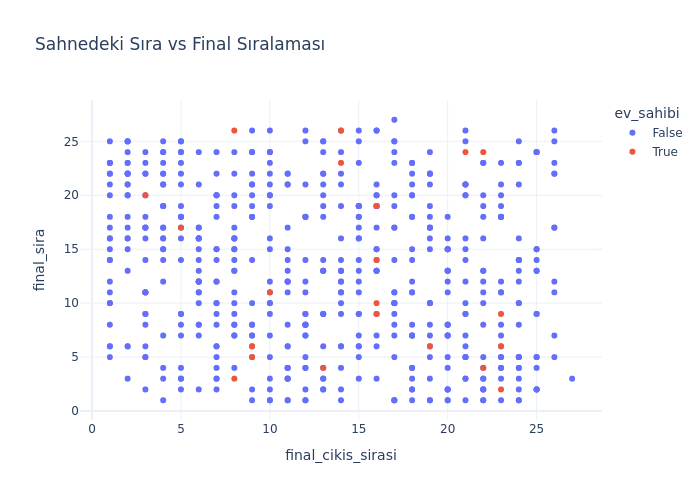

In [9]:
dagilim_grafigi(finale_kalanlar.dropna(subset=['final_cikis_sirasi']),
                x_sutunu='final_cikis_sirasi', y_sutunu='final_sira',
                renk_sutunu='ev_sahibi',
                baslik='Sahnedeki Sıra vs Final Sıralaması')

📊 **Sahne çıkış sırası vs sıralama:** Sona doğru çıkan şarkılar jürinin/izleyicinin aklında daha taze kalabilir, bu yüzden hafif avantajlı olabilir. Grafikte net bir eğilim **var mı yok mu** ona bak — bazen ‘beklediğimiz etki veride görünmez’ ve bu da geçerli bir bulgudur.

## Adım 6 (Seçenek): Tele vs Jüri Puanı (2016+)

📈 Dağılım grafiği çiziliyor: juri_puan_final - tele_puan_final


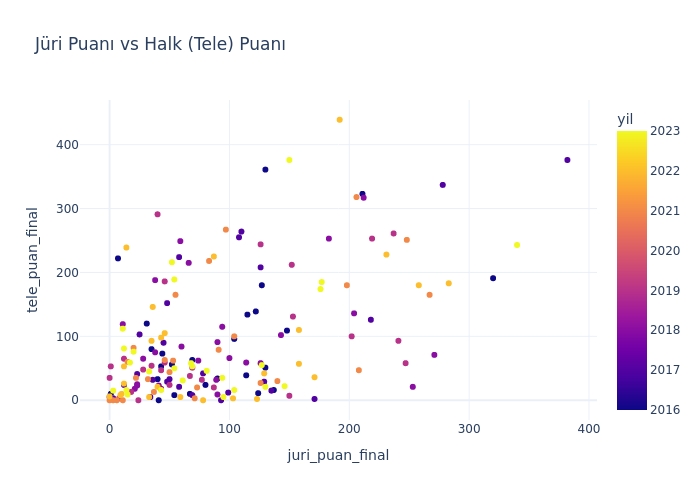

In [10]:
yeni_donem = esc[esc['yil'] >= 2016].dropna(subset=['tele_puan_final', 'juri_puan_final'])
dagilim_grafigi(yeni_donem, x_sutunu='juri_puan_final', y_sutunu='tele_puan_final',
                renk_sutunu='yil', baslik='Jüri Puanı vs Halk (Tele) Puanı')

📊 **Jüri vs halk puanı:** Köşegen üstündeki şarkılarda ikisi anlaşır. Köşegenden **uzak** şarkılar, jüri ile halkın **anlaşmadığı** şarkılardır (biri çok sevdi, diğeri sevmedi). İlginç tartışma: uzman görüşü mü, halk oyu mu daha ‘doğru’? İki kitle her zaman aynı şeyi sevmez.

**Görev:** Halk ile jüri köşegenden uzak şarkılar var mı? Hangileri?

---
## 🌍 Adım 7 (YENİ): Coğrafya Etkisi — Ev Sahibine Uzaklık

**Hipotez:** Ev sahibi ülkeye yakın ülkeler — yerel jüri ve tele desteğiyle — daha iyi mi sıralanıyor?

Eurovision'da **bloc voting** (komşu oylama) kalıbı sıkça konuşulur. Bunu veriyle test edelim.

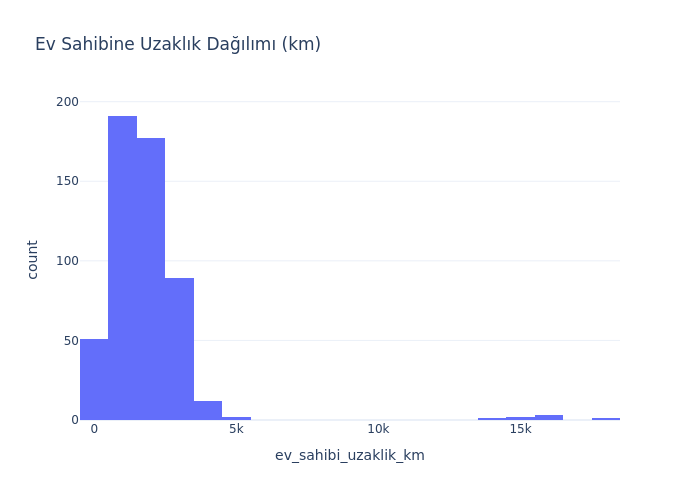

In [11]:
# Ev sahibine uzaklık dağılımı
histogram(finale_kalanlar.dropna(subset=['ev_sahibi_uzaklik_km']),
          sutun='ev_sahibi_uzaklik_km',
          baslik='Ev Sahibine Uzaklık Dağılımı (km)')

📈 Dağılım grafiği çiziliyor: ev_sahibi_uzaklik_km - final_sira


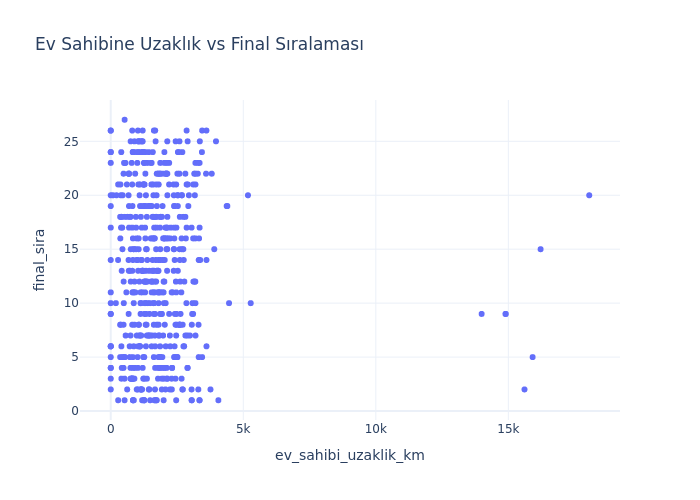

In [12]:
# Uzaklık vs sıralama: yakın ülkeler daha iyi mi?
dagilim_grafigi(finale_kalanlar.dropna(subset=['ev_sahibi_uzaklik_km']),
                x_sutunu='ev_sahibi_uzaklik_km',
                y_sutunu='final_sira',
                baslik='Ev Sahibine Uzaklık vs Final Sıralaması')

📊 **Uzaklık vs sıralama:** Ev sahibine yakın ülkeler daha mı iyi sıralanıyor? Noktalarda hafif bir eğilim varsa, bu ‘komşu/bölge etkisinin’ ilk işaretidir. Bir sonraki hücrede bunu **sayıyla** test edeceğiz.

In [13]:
# Sayısal kıyas: yakın (<1500 km) vs uzak (>3000 km)
import numpy as np
yakin = finale_kalanlar[finale_kalanlar['ev_sahibi_uzaklik_km'] < 1500]
uzak = finale_kalanlar[finale_kalanlar['ev_sahibi_uzaklik_km'] > 3000]
print(f'<1500 km: {len(yakin)} katılım, ortalama sıra: {yakin["final_sira"].mean():.1f}')
print(f'>3000 km: {len(uzak)} katılım, ortalama sıra: {uzak["final_sira"].mean():.1f}')
print(f'\nYakın ülkelerin top 10 oranı: %{(yakin["ilk_10"].mean()*100):.1f}')
print(f'Uzak ülkelerin top 10 oranı : %{(uzak["ilk_10"].mean()*100):.1f}')

<1500 km: 242 katılım, ortalama sıra: 13.0
>3000 km: 58 katılım, ortalama sıra: 13.4

Yakın ülkelerin top 10 oranı: %41.3
Uzak ülkelerin top 10 oranı : %43.1


📊 **Yakın (<1500 km) vs uzak (>3000 km):** Grafikteki sezgiyi sayıya döküyoruz. Yakın ülkelerin ortalama sırası ve ‘ilk 10’ oranı daha iyiyse, coğrafyanın etkisi **somutlaşır**. Göz kararı değil, sayı konuşur — sunumda en ikna edici an budur.

**Görev:** Yakın ülkeler gerçekten daha iyi mi sıralanıyor? Sayılarla cevaplayın.

## Adım 8: "İlk 10'a Girer mi?" Tahmin Modeli

Sınıflandırma modeli — bu sefer **coğrafya** dahil!

🪓 Eğitim: 423 örnek | Test: 106 örnek
🌲🌲🌲 Rastgele orman eğitiliyor (100 ağaç)...
✅ Eğitim tamamlandı.


🎯 Doğruluk: %61.32


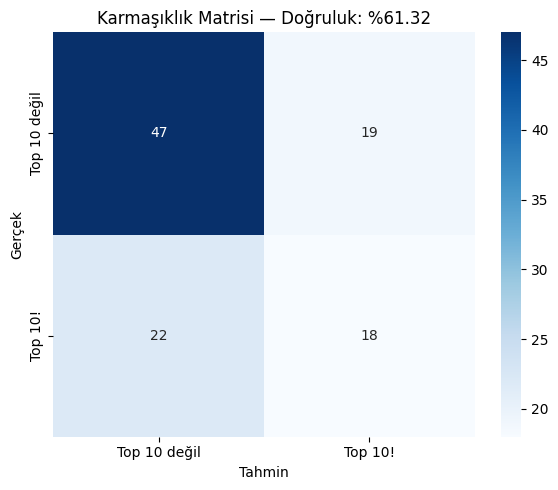

In [14]:
model_veri = esc[esc['finale_kaldı']].copy()
ozellikler = ['yil', 'ulke', 'final_cikis_sirasi', 'yari_final_no',
              'ev_sahibi', 'ev_sahibi_uzaklik_km']
model_veri = model_veri.dropna(subset=['final_cikis_sirasi', 'ev_sahibi_uzaklik_km'])
X = pd.get_dummies(model_veri[ozellikler], columns=['ulke'])
y = model_veri['ilk_10']

X_egitim, X_test, y_egitim, y_test = egitim_test_bol(X, y)
model = rastgele_orman_egit(X_egitim, y_egitim)
dogruluk = model_degerlendir(model, X_test, y_test, sinif_adlari=['Top 10 değil', 'Top 10!'])

📊 **‘İlk 10’ modelinin doğruluğu nasıl yorumlanır?** Eurovision sonucu büyük ölçüde **öznel** (şarkı, sahne, jeopolitik). Bu yüzden doğruluk, kanser modeli kadar yüksek olmayabilir — ve bu **normaldir**. Önemli olan modelin **baseline'ı geçmesi** ve hangi faktörleri önemli bulduğudur. ‘Düşük doğruluk = başarısız proje’ **değildir**; bazı olaylar doğası gereği zor tahmin edilir.

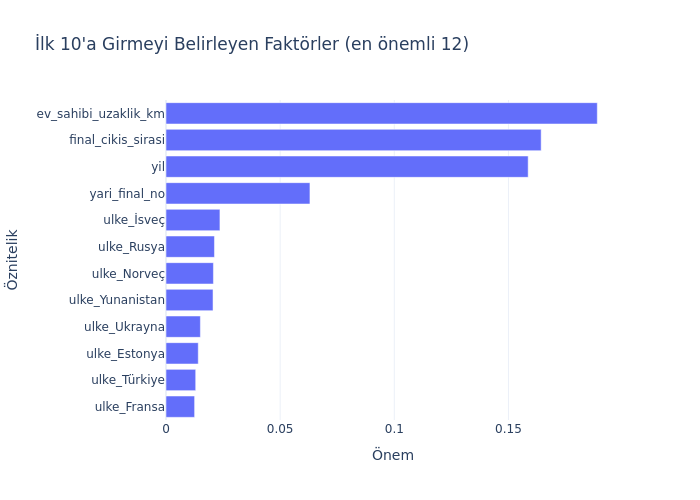

In [15]:
oznitelik_onemi_grafigi(model, oznitelik_adlari=list(X.columns), en_iyi_n=12,
                         baslik='İlk 10\'a Girmeyi Belirleyen Faktörler')

📊 **Öznitelik önemi:** Model ‘ilk 10'a girmeyi’ en çok hangi faktörlerle açıklıyor? `ev_sahibi_uzaklik_km` üst sıralardaysa, coğrafyanın gerçekten önemli olduğunun **bir başka kanıtı** olur — yani farklı yöntemler (gruplama + model) aynı sonuca işaret eder, bu da bulgunu güçlendirir.

**Görev:** `ev_sahibi_uzaklik_km` özniteliği önem sıralamasında nerede? Diğer önemli faktörlerle karşılaştırın.

---
### 👥 Grup Tartışması
- Modeliniz 'ilk 10'a girer mi' tahmininde **uzaklık/komşuluk** önemli buldu mu? Eurovision **tamamen adil** olsaydı hangi öznitelikler önemli **olmamalıydı**?
- Bir model dünyadaki bir 'haksızlığı' öğrenip tekrar üretebilir. Bu neden tehlikeli olabilir? (örn. işe alım, kredi)

## Adım 9: Sunum için notlarınız

- Toplam katılım: ___ (gerçek 2000-2023)
- Türkiye'nin **en iyi yılı**: ___ (sanatçı: ___, şarkı: ___)
- En çok kazanan ülke: ___ (___ kez)
- Ev sahibi avantajı: ___ sıra iyileşme
- 🌍 Yakın (<1500 km) ortalama sıra: ___ vs Uzak (>3000 km): ___
- Modelin doğruluğu: %___
- En önemli 3 öznitelik:
  1. ___________
  2. ___________
  3. ___________
- **Şaşırtıcı bulgu**: _________________________
- **İlginç soru**: Eurovision sadece müzik mi yoksa kültürel komşuluk da var mı? Komşu ülkeler birbirine daha çok puan veriyor mu?

📝 Bilimsel yöntem şablonunu (Google Slides) doldurun!

## 🎤 Sunum & Yorumlama Rehberi

> Bu bölüm, projeyi **son gün sunarken** ne anlatacağını ve sonuçları **nasıl yorumlayacağını** özetler. Ezberleme — kendi cümlelerinle anlat.

**🎤 Ana mesaj:** *“Eurovision sadece müzik değil: ev sahibi avantajı, sahne sırası ve özellikle **komşu oylaması** sonuçları ölçülebilir biçimde etkiliyor.”*

**Grafik sırası:** ① Türkiye tarihçesi (2003 zaferi, sıcak giriş) → ② en çok kazananlar → ③ uzaklık vs puan (komşu oylaması — **projenin yıldızı**) → ④ Türkiye–Azerbaycan örneği → ⑤ ‘ilk 10’ modeli + öznitelik önemi.

**Yorumlama anahtarları:** komşu etkisini **sayıyla** söyle (‘0–500 km'ye verilen puan, 5000+ km'nin ~__ katı’); ev sahibi avantajını ‘ortalama __ sıra iyileşme’ olarak ifade et; modelin düşük doğruluğunu **dürüstçe** açıkla.

**Sık hatalar:** ❌ ‘komşu yüksek puan = kesin torpil’ (ortak kültür de olabilir) · ❌ tek ülkeden genel kural çıkarmak · ❌ modelin %100 olmamasını başarısızlık sanmak.

---
## 🚀 BONUS — Komşu Oylama Detayı (Eurovision'un en bilinen ön yargısı)

Şimdi gerçek **oy verilerine** bakalım: hangi ülke hangine kaç puan vermiş?

**Veri seti:** `eurovision_oylar.csv` — 21165 GERÇEK oy kaydı (her satır: yıl, oy_veren, oy_alan, puan, uzaklık_km)

In [16]:
oylar = veri_yukle('input_data/eurovision_oylar.csv')
print(f'\nOrtalama puan: {oylar["puan"].mean():.2f}')

📂 'input_data/eurovision_oylar.csv' okunuyor...
✅ Yüklendi: 21165 satır × 7 sütun

İlk 5 satır:
    yil oy_veren_ulke oy_alan_ulke  puan  tele_puan  juri_puan   uzaklik_km
0  2000     Avusturya    Danimarka    10        NaN        NaN   870.170887
1  2000     Avusturya        Rusya     7        NaN        NaN  1669.722046
2  2000     Avusturya      Letonya     8        NaN        NaN  1102.029611
3  2000     Avusturya      Estonya     3        NaN        NaN  1361.997929
4  2000     Avusturya      Almanya    12        NaN        NaN   523.394347

Ortalama puan: 3.14


📊 **Oy verisine geçiş:** 21.165 satırlık bu set ‘kim kime kaç puan verdi’yi tutar (ortalama puan ~3,1). Artık ülke ortalamalarına değil, **ülkeler arası ilişkilere** bakacağız — komşu oylamasının asıl kanıtı buradadır.

  uzaklik_kategori      puan
0         0-500 km  5.799163
1         500-1000  3.731049
2        1000-2000  2.781670
3        2000-3000  2.688260
4        3000-5000  2.471179
5         5000+ km  4.657250


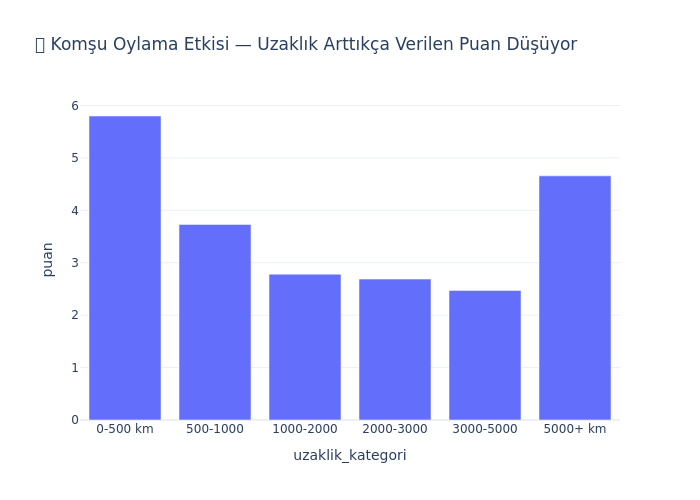

In [17]:
# Uzaklık aralıklarına göre ortalama puan
import numpy as np
oylar['uzaklik_kategori'] = pd.cut(oylar['uzaklik_km'],
    bins=[0, 500, 1000, 2000, 3000, 5000, 20000],
    labels=['0-500 km', '500-1000', '1000-2000', '2000-3000', '3000-5000', '5000+ km'])
ortalama = oylar.groupby('uzaklik_kategori', observed=True)['puan'].mean().reset_index()
print(ortalama)

import plotly.express as px
fig = px.bar(ortalama, x='uzaklik_kategori', y='puan',
             title='🌍 Komşu Oylama Etkisi — Uzaklık Arttıkça Verilen Puan Düşüyor')
fig.show()

📊 **‘Komşu oylaması’ grafiği:** Çubuklar uzaklık arttıkça **düşüyorsa**, ülkeler coğrafi/kültürel olarak yakın komşularına ortalamadan **daha yüksek** puan veriyor demektir. Bu, müziğin yanında **kültür ve siyasetin** de oyları etkilediğinin sayısal kanıtıdır. ⚠️ Bu bir **eğilimdir**; her komşu çifti için geçerli olmak zorunda değildir.

**Gözlem:** 0-500 km arası komşulara verilen ortalama puan, 5000+ km uzaklara verilenden **kaç kat fazla**?

Bu istatistiksel bir sonuç değil — **literatürdeki bilinen Eurovision bias'ı.** Akademik makalelerde de var (Gatherer 2006, Spierdijk & Vellekoop 2009).

---
### 👥 Grup Tartışması
- Komşu ülkeler birbirine daha çok puan veriyor. Bu **siyasi/kültürel yakınlık** mı, yoksa **benzer müzik zevki** mi? İkisini nasıl ayırt edebiliriz?
- Veride bir örüntü görmek, onun **sebebini** bildiğimiz anlamına gelir mi? (*'korelasyon ≠ nedensellik'*)

In [18]:
# Türkiye - Azerbaycan dostluğu efsanesi: gerçek mi?
tr_az = oylar[(oylar['oy_veren_ulke'] == 'Türkiye') & (oylar['oy_alan_ulke'] == 'Azerbaycan')]
az_tr = oylar[(oylar['oy_veren_ulke'] == 'Azerbaycan') & (oylar['oy_alan_ulke'] == 'Türkiye')]
print(f'🇹🇷 → 🇦🇿 Türkiye\'nin Azerbaycan\'a verdiği ortalama puan: {tr_az["puan"].mean():.2f}')
print(f'🇦🇿 → 🇹🇷 Azerbaycan\'ın Türkiye\'ye verdiği ortalama puan: {az_tr["puan"].mean():.2f}')
print(f'\nGenel ortalama: {oylar["puan"].mean():.2f}')
print(f'\nYani Türkiye-Azerbaycan oylaması ortalamadan ~{tr_az["puan"].mean()/oylar["puan"].mean():.1f}x daha yüksek!')

🇹🇷 → 🇦🇿 Türkiye'nin Azerbaycan'a verdiği ortalama puan: 12.00
🇦🇿 → 🇹🇷 Azerbaycan'ın Türkiye'ye verdiği ortalama puan: 12.00

Genel ortalama: 3.14

Yani Türkiye-Azerbaycan oylaması ortalamadan ~3.8x daha yüksek!


📊 **Türkiye–Azerbaycan:** İki ülkenin birbirine verdiği ortalama puan, genel ortalamanın **çok üstünde**. Bu, soyut ‘komşu etkisi’ bulgusunun herkesin bildiği **somut** bir örneği — sunumda akılda kalır. ⚠️ Ortak dil/kültür/müzik zevki de bunu açıklayabilir; ‘torpil’ demeden önce düşün.

In [19]:
# Skandinav bloğu örneği: İsveç ve Norveç birbirine ne veriyor?
se_no = oylar[(oylar['oy_veren_ulke'] == 'İsveç') & (oylar['oy_alan_ulke'] == 'Norveç')]
no_se = oylar[(oylar['oy_veren_ulke'] == 'Norveç') & (oylar['oy_alan_ulke'] == 'İsveç')]
print(f'🇸🇪 → 🇳🇴 İsveç → Norveç ortalama: {se_no["puan"].mean():.2f}')
print(f'🇳🇴 → 🇸🇪 Norveç → İsveç ortalama: {no_se["puan"].mean():.2f}')

🇸🇪 → 🇳🇴 İsveç → Norveç ortalama: 8.32
🇳🇴 → 🇸🇪 Norveç → İsveç ortalama: 10.43


## 🚀 BONUS Hızlı Bitirenler İçin

1. **Kendi ülke çiftiniz:** Yunanistan-Kıbrıs, Sırbistan-Karadağ, Romanya-Moldova — komşu blokları test edin
2. **Tele vs jüri komşuluğu:** Halk komşuya 2x oy veriyor mu, jüri daha tarafsız mı? (`tele_puan` ve `juri_puan` sütunlarını kullanın, 2016+)
3. **En "adaletsiz" puan:** Coğrafyaya göre beklenen puandan en çok sapan oy hangisi?
4. **Yıllar içinde değişim:** 2009'da jüri sistemi geldi. O öncesi ve sonrası komşu etkisi farklı mı?
5. **Türkiye geri dönerse:** Türkiye 2026'da geri dönse, hangi ülkelerden yüksek puan alır? (En yakın komşulara bakın)

## 🆘 Yardım — Sık Karşılaşılan Hatalar

**❌ `KeyError: 'puan'`** → eurovision.csv'de `final_puan`, eurovision_oylar.csv'de `puan`

**❌ Türkiye 2024'te niye yok?** → Veri 2000-2023. Türkiye 2013'ten beri katılmıyor

**❌ `final_sira` NaN** → Yarı finalden elenenler. `esc[esc['finale_kaldı']]` ile filtreleyin

**❌ `tele_puan_final` çoğunlukla NaN** → 2016 öncesi ayrı yoktu. `esc[esc['yil'] >= 2016]` filtresi

**❌ `ev_sahibi_uzaklik_km` NaN** → Bilinmeyen ülke (Yugoslavya gibi tarihsel ülkeler). `dropna()` ile çıkarın

**❌ Model çok iyi (%99)** → Veri sızıntısı! `final_puan` veya `final_sira` X'te olmamalı

---
# 🧑‍🏫 Öğretmen Rehberi & Cevap Anahtarı
*Bu bölüm öğretmen içindir: beklenen sonuçlar, sık takılma noktaları ve tartışma soruları. Öğrenciler projeyi yaptıktan sonra bakabilir.*

# 🎓 PROJE 4 EĞİTMEN — Eurovision (Gerçek Veri)
## Mini Proje Saha Rehberi

**Bu notebook eğitmenler içindir.**

## ✅ Veri Hakkında — GERÇEK

Bu **gerçek tarihsel veridir** — Spijkervet/eurovision-dataset GitHub repo'sundan, eurovisionworld.com kayıtlarına dayalı. 916 katılım (2000-2023, 24 yıl, 50 ülke).

Sınıfta açıkça söyleyin:

> "Bu **gerçek** Eurovision verisi. Sertab Erener'in 2003'te kazandığını, Türkiye'nin 2013'ten beri katılmadığını veride göreceksiniz."

## 👥 Bu Projeyi Kim Seçer?
- Eğlenceli/popüler kültür sevenler
- Müzik ilgisi olanlar, Türkçe pop sevenler
- Türkiye'nin uluslararası rekabetini merak edenler
- "Ciddi konu yorgunu" — daha hafif bir ton arayanlar

## 🎯 Beklenen Çıktı (2 saat sonunda)
- Türkiye'nin 13 yıllık tarihi (2000-2012) gösterilmiş
- En çok kazanan ülkeler tablosu
- Ev sahibi avantajı sayısal olarak
- Sahnedeki çıkış sırası analizi
- "İlk 10'a girer mi?" tahmin modeli

## 📊 Beklenen Sayısal Sonuçlar
- **Toplam katılım:** 916 (gerçek)
- **Ülke sayısı:** 50
- **Türkiye en iyi yıl:** 2003 — Sertab Erener — Every Way That I Can — 1. sıra ✨
- **Türkiye'nin 13 katılımında ortalama sırası:** ~5-6 (oldukça iyi performans!)
- **En çok kazanan (2000-2023):** İsveç ve Ukrayna 3'er kez
- **2003 Türkiye, 2004 Ukrayna, 2012 İsveç vb.** — gerçek tarih
- **Ev sahibi avantajı:** ~3-5 sıra iyileşme
- **🌍 Coğrafya etkisi:** <1500 km ortalama sıra ~12, >3000 km ~15 (2-3 sıra avantaj)
- **Komşu oylama:** <500 km komşulara verilen ortalama puan ~6, 5000+ km uzaklara ~2.5 (~%140 fark!)
- **Türkiye ↔ Azerbaycan:** Karşılıklı ortalama puan ~10-12 (genel ortalama 3.14)
- **"İlk 10" model doğruluğu:** ~%52-65 (baseline ~%50). Eurovision kazananını tahmin gerçekten zor — bu pedagojik olarak değerli; kaotik sistemleri tanıma fırsatı

## ⚠️ Tipik Takılma Noktaları

**1. "Veride 2024 niye yok?"**
→ Veri seti 2023'e kadar (Spijkervet release Mayıs 2023). 2024 verisi resmi sitede mevcut ama bu sürümde yok

**2. "final_sira NaN gördüm — hata mı?"**
→ Yarı finalden elenenler için final_sira yok. Bu **gerçek** — modele sadece `finale_kaldı=True` olanları verin

**3. "Modelim %50, kötü mü?"**
→ Baseline ~%50 (top 10 = top 26 katılımcının %38'i). %70+ alıyorsanız iyi. Hayalinizdeki %95'lere ulaşmak Eurovision'un yapısı gereği zor

**4. "tele_puan_final çoğunlukla NaN"**
→ 2016 öncesi tele/jüri ayrı yoktu. Sadece `yil >= 2016` filtresi gerek

**5. Türkiye 2003 zafer detayı**
→ Öğrenciler heyecanla "o şarkıyı dinleyebilir miyiz?" diye sorabilir. YouTube'da "Sertab Erener Every Way That I Can" ile bulunur. Sınıfta 30 saniye dinletirseniz coşkulu bir an olur

**6. "Veri sızıntısı şüphesi"**
→ `final_puan` veya `final_sira` X içinde olmamalı (hedef = ilk_10 = final_sira ≤ 10). Bunu öğrencilerle birlikte kontrol edin

## 🎯 Derinleştirme Soruları

1. "İsveç en çok kazanan ülkelerden — niye?" → İsveç pop endüstrisi çok güçlü (ABBA, Avicii kültürü, Melodifestivalen elemeleri uluslararası seviye)
2. "Türkiye 2003 zaferi: Sertab kaç ülkeden 12 puan aldı?" → votes.csv ile araştırılabilir (bonus)
3. "2009 Norveç (Alexander Rybak) rekorlu zafer (387 puan) — niye o kadar yüksek?" → Eski puanlama sistemi, az ülke 12'lik puan veriyor
4. "Almanya 2010 (Lena Meyer-Landrut) zaferinden sonra niye düştü?" → Karakter etkisi, sürdürülemez
5. "Tele vs jüri farkı en büyük olan şarkı?" → 2016+ yıllarda halk jürinin tersine oy verdiği örnekler

## 💭 Etik / Sosyal Tartışma

Eurovision "basit" görünür ama veride ilginç sorular taşır:

> "Eurovision sadece müzik mi? Yoksa kültürel komşuluk da var mı?"

Veride gözlemlenebilir kalıplar:
- **2003 Türkiye galibiyeti:** Sertab Erener — Türk pop sanatçısının uluslararası bir başarısı
- **Komşu oylama:** Türkiye-Azerbaycan, Yunanistan-Kıbrıs, Skandinavya bloğu — gerçek mi efsane mi?
- **Dil etkisi:** İngilizce şarkılar avantajlı mı?

**Algoritma boyutu:**
- Spotify, YouTube algoritmaları artık müzik tüketimini şekillendiriyor. Eurovision'un "insan oyu" formatı hala önemli mi?
- Modelinizi geliştirilse, Avrupa Yayın Birliği bunu "adil oylama denetimi" için kullanır mı?

## 🎤 Sunum Koçluğu

Bu projenin sunumu **eğlenceli ve duygusal olabilir** — bunu kucaklayın:
- Türkiye'nin 13 yıllık sıralama grafiği (drama: 2003 zaferi → düşüş → çekilme)
- En önemli faktörler grafiği
- **Sertab Erener anısı:** 30 saniye "Every Way That I Can" dinlettirmek (kayıt değil canlı arama)
- **Hipotetik soru:** "Yeni bir Türkiye Eurovision şarkısı yapılsa, hangi özellikler kazandırır?" — modelle deneyin
- Eğlenceli kapanış: Sınıfa "siz olsanız nasıl bir Türkiye Eurovision şarkısı yazardınız?" sorun

## 🌍 Coğrafya Bölümü (YENİ — Adım 7 + Bonus)

**Seviye 1 (ana model):** `ev_sahibi_uzaklik_km` özniteliği eklendi
- Hipotez: Ev sahibine yakın ülkeler avantajlı mı?
- Beklenen: Var ama dramatik değil (~2-3 sıra fark)
- Modelde önem sıralamasında orta seviyede çıkar

**Seviye 2 (bonus — eurovision_oylar.csv):** 21165 gerçek oy kaydı
- Beklenen kalıplar:
  - <500 km komşulara verilen ortalama puan: ~6 (genel ort 3.14)
  - 5000+ km uzaklara: ~2.5
  - Türkiye→Azerbaycan: ortalama ~10-12 puan (literatürde "blok oylamanın anıtı")
  - İsveç↔Norveç: ortalama ~7-9 puan
  - Yunanistan↔Kıbrıs: en yüksek karşılıklı ortalama ~9-11 puan

**Yönlendirme soruları:**
- "Eurovision sadece müzik mi yoksa **kültürel diplomasi** mi?"
- "Bu komşu kalıbı **adil mi**? Şarkıyı duymadan Yunanistan'ın Kıbrıs'a 12 puan vereceğini biliyoruz"
- "Akademik makaleler bunu çalıştı (Gatherer 2006). Bizim 'amatör analizimiz' aynı sonuca vardı — bilim böyle çalışır!"
